## **Binary Logistic Regression**

### **Purpose**

The purpose of this model is to classify whether a word entered by the user is likely to be easy or difficult for children at a specific age threshold. Since the user input is expected to be a single word, the model was designed to use only features that can be automatically extracted from a single word.

For this reason, the model does not require additional user-provided information. Instead, it uses word-level linguistic features such as word length, estimated syllable count, word frequency, vowel ratio, and maximum consonant run. These features are used to train a binary logistic regression model that predicts whether the word is easy or difficult based on the selected Age of Acquisition threshold.

### **Structure**
This notebook is organized into the following sections

1. Dataset loading and visualization  
2. Feature extraction and label creation  
3. Train / validation / test split  
4. Logistic regression model implementation  
5. Model training and validation-based tuning  
6. Final test result evaluation  
7. Example word prediction

In [1]:
!pip install wordfreq -q

In [2]:
import re
import numpy as np
import pandas as pd
import wordfreq
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.metrics import matthews_corrcoef, confusion_matrix
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)
print('Total rows:', len(df))
df.head()

Saving AoA_refined_dataset_v3_freq5.xlsx to AoA_refined_dataset_v3_freq5 (5).xlsx
Total rows: 5889


,Word,Alternative.spelling,Freq_pm,Dom_PoS_SUBTLEX,Nletters,Nphon,Nsyll,Lemma_highest_PoS,AoA_Kup,Perc_known,AoA_Kup_lem,Perc_known_lem,AoA_Bird_lem,AoA_Bristol_lem,AoA_Cort_lem,AoA_Schock,Perc_known_final,AoA_final,Age_Group,AoA_source
0,a,a,20415.274510,Article,1,1,1,a,2.893384,1.0,2.893384,1.0,3.156247,NaN,NaN,NaN,1.0,2.893384,below_6,AoA_Kup
1,abandon,abandon,8.098039,Verb,7,7,3,abandon,8.320000,1.0,8.320000,1.0,NaN,NaN,NaN,NaN,1.0,8.320000,age_8_plus,AoA_Kup
2,abandoned,abandoned,13.294118,Verb,9,8,3,abandon,NaN,NaN,8.320000,1.0,NaN,NaN,NaN,NaN,1.0,8.320000,age_8_plus,AoA_Kup_lem
3,abducted,abducted,5.000000,Verb,8,8,3,abduct,NaN,NaN,11.260000,1.0,NaN,NaN,NaN,9.48848,1.0,11.260000,age_8_plus,AoA_Kup_lem
4,abilities,abilities,6.117647,Noun,9,8,4,ability,NaN,NaN,8.840000,1.0,NaN,8.97764,NaN,NaN,1.0,8.840000,age_8_plus,AoA_Kup_lem


In [3]:
# Hyperparameters
PARAMETERS = {
    'seed': 42,
    'word_col': 'Word',
    'target_col': 'AoA_Kup',
    'perc_known_col': 'Perc_known',
    'threshold_age': 7.0,
    'perc_known_min': 0.7,
    'test_size': 0.2,
    'val_size_within_tv': 0.2,
    'alphas': [0.001, 0.01, 0.1, 1.0],
    'lr_candidates': [0.001, 0.005, 0.01],
    'epochs': 5000,
    'default_threshold': 0.5,
    'threshold_start': 0.1,
    'threshold_end': 0.9,
    'threshold_step': 0.02,
}

# Feature list to extract for training
FEATURES = ['n_letters', 'n_syll_est', 'zipf_score', 'vowel_ratio', 'max_consonant_run']

# Output message based on predicted probability
HEDGE_BANDS = [
    (0.25, 'Most children aged {age} would likely know this word'),
    (0.40, 'Children aged {age} would likely know this word'),
    (0.60, 'This word may or may not be familiar to children aged {age}'),
    (0.75, 'This word may be unfamiliar to children aged {age}'),
    (1.00, 'This word is likely unfamiliar to children aged {age}')
]

In [4]:
# Extract only lowercase alphabets from a word
def clean_word(word):
    return re.sub(r'[^a-z]', '', str(word).lower().strip())

# Convert AoA value to binary label based on age threshold
def to_binary(v, threshold_age):
    return 1 if v >= threshold_age else 0

# Estimate syllable count using rule-based vowel detection
def estimate_syllables(word):
    w = clean_word(word) # Change to lowercase
    if not w:
        return 1
    vowels = 'aeiouy'
    count = 0
    prev_is_vowel = False

    # Syllable count if new vowel group starts
    for ch in w:
        is_vowel = ch in vowels
        if is_vowel and not prev_is_vowel:
            count += 1
        prev_is_vowel = is_vowel

    # Silent trailing e
    if w.endswith('e') and count > 1:
        count -= 1
    return max(count, 1)

# Extract 5 linguistic features from a single word
def build_features(word):
    w = str(word).lower().strip()
    cw = clean_word(w)
    n_letters = len(cw)
    n_syll_est = estimate_syllables(w)
    zipf = wordfreq.zipf_frequency(cw, 'en')

    # Calculate vowel ratio
    vowels = 'aeiouy'
    n_vowels = sum(1 for ch in cw if ch in vowels)
    vowel_ratio = n_vowels / n_letters if n_letters > 0 else 0.0

    # Calculate maximum consecutive consonant run
    max_run = 0
    current_run = 0
    for ch in cw:
        if ch not in vowels:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0

    # Return feature dictionary
    return {
        'n_letters': float(n_letters),
        'n_syll_est': float(n_syll_est),
        'zipf_score': float(zipf),
        'vowel_ratio': float(vowel_ratio),
        'max_consonant_run': float(max_run),
    }

# Normalize inflected word forms to base form
def normalize_word_form(word):
    w = clean_word(word)
    if not w:
        return w
    # Convert -ies to -y (ex. babies -> baby)
    if len(w) > 4 and w.endswith('ies'):
        return w[:-3] + 'y'
    # Remove 's' (ex. boxes -> box)
    if len(w) > 4 and w.endswith('es') and w.endswith(('ses', 'xes', 'zes', 'ches', 'shes')):
        return w[:-2]
    # Remove 's' (ex. cats -> cat)
    if len(w) > 3 and w.endswith('s') and not w.endswith('ss') and not w.endswith('sis'):
        return w[:-1]
    return w

# Map predicted probability to a natural language message
def hedge_message(p, threshold_age):
    age = int(threshold_age)
    for upper, message in HEDGE_BANDS:
        if p < upper:
            return message.format(age=age)
    return HEDGE_BANDS[-1][1].format(age=age)

Final dataset size: 4253
easy (<7): 2084
difficult (>=7): 2169


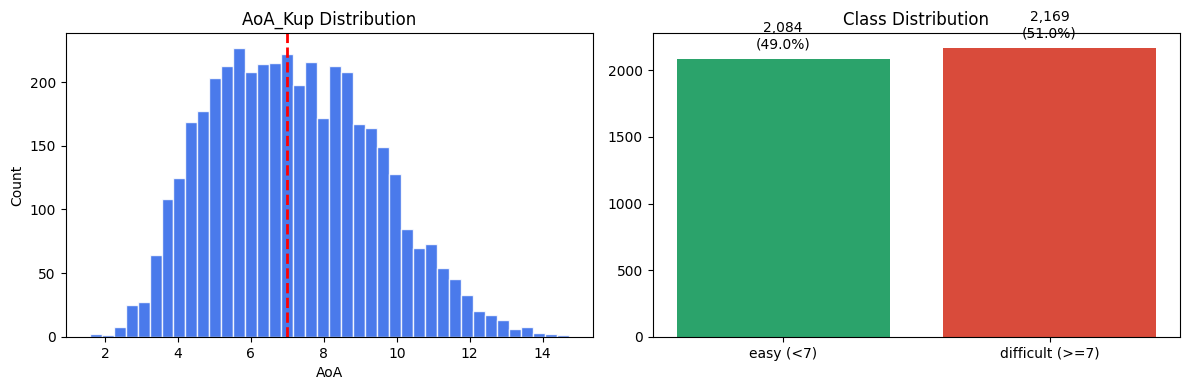

In [5]:
df = df[df[PARAMETERS['target_col']].notna()].copy()
df = df[df[PARAMETERS['perc_known_col']] >= PARAMETERS['perc_known_min']].copy()
df[PARAMETERS['word_col']] = df[PARAMETERS['word_col']].astype(str)

# Extract linguistic features from each word
feature_df = df[PARAMETERS['word_col']].apply(build_features).apply(pd.Series)
df = pd.concat([df, feature_df], axis=1)
# Remove rows with missing required feature or target values
df = df.dropna(subset=FEATURES + [PARAMETERS['target_col']]).reset_index(drop=True)
# Create binary easy/difficult labels
df['label'] = df[PARAMETERS['target_col']].apply(
    lambda value: to_binary(value, PARAMETERS['threshold_age'])
)
# Define label names
LABELS = [
    f"easy (<{PARAMETERS['threshold_age']:g})",
    f"difficult (>={PARAMETERS['threshold_age']:g})"
]
print('Final dataset size:', len(df))
label_counts = df['label'].value_counts().sort_index()
for label_id, count in label_counts.items():
    print(f'{LABELS[label_id]}: {count}')

# Store the number of samples for each class
counts = df['label'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(
    df[PARAMETERS['target_col']],
    bins=40,
    color='#2A63E8',
    alpha=0.85,
    edgecolor='white'
)
axes[0].axvline(
    PARAMETERS['threshold_age'],
    color='red',
    linestyle='--',
    linewidth=2
)
axes[0].set_title(f"{PARAMETERS['target_col']} Distribution")
axes[0].set_xlabel('AoA')
axes[0].set_ylabel('Count')
# Visualize the class distribution to check the balance
axes[1].bar(
    [LABELS[i] for i in counts.index],
    counts.values,
    color=['#2BA36B', '#D94B3B']
)
axes[1].set_title(f"Class Distribution")

# Display the count and percentage
for i, value in enumerate(counts.values):
    axes[1].text(
        i,
        value + 80,
        f'{value:,}\n({value / len(df) * 100:.1f}%)',
        ha='center'
    )
plt.tight_layout()
plt.show()

In [6]:
# Convert feature columns and label into x,y
X = df[FEATURES].values.astype(float)
y = df['label'].values.astype(int)
# Split the dataset into train + validation set and test set
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=PARAMETERS['test_size'],
    random_state=PARAMETERS['seed'],
    stratify=y
)

# Split to training set and validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=PARAMETERS['val_size_within_tv'],
    random_state=PARAMETERS['seed'],
    stratify=y_tv
)
print('Train:', len(X_train), '| Val:', len(X_val), '| Test:', len(X_test))

Train: 2721 | Val: 681 | Test: 851


In [7]:
# Normalizing training features to mean 0 and standard deviation 1
class StandardScaler:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)          # Store feature mean
        self.scale_ = X.std(axis=0)          # Store feature std
        self.scale_[self.scale_ == 0] = 1.0  # Prevent division by 0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.scale_

# L2 regularization logistic regression
class BinaryLogisticRegression:
    def __init__(self, alpha=0.01, lr=0.01, epochs=500):
        self.alpha = alpha   # Regularization strength
        self.lr = lr
        self.epochs = epochs

    # Sigmoid function
    def _sigmoid(self, z):
        return np.where(
            z >= 0,
            1.0 / (1.0 + np.exp(-z)),
            np.exp(z) / (1.0 + np.exp(z))
        )

    def fit(self, X, y, print_every=50):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        # Get the number of samples and features
        n, p = X.shape
        self.w_ = np.zeros(p, dtype=float)
        self.b_ = 0.0
        self.loss_history_ = []

        # Train the model
        for epoch in range(1, self.epochs + 1):
            z = X @ self.w_ + self.b_
            p_hat = np.clip(self._sigmoid(z), 1e-12, 1 - 1e-12)

            # Compute the binary cross-entropy loss
            ce = -(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))
            loss = ce.mean() + self.alpha * (self.w_ ** 2).sum()
            self.loss_history_.append(loss)

            # Divide prediction error by sample size for gradient calculation
            residual = (p_hat - y) / n
            grad_w = X.T @ residual + 2 * self.alpha * self.w_
            grad_b = residual.sum()

            # Gradually reduce the learning rate as epochs increase
            lr_t = self.lr / (1 + 0.001 * epoch)
            self.w_ -= lr_t * grad_w
            self.b_ -= lr_t * grad_b
            if epoch == 1 or epoch % print_every == 0 or epoch == self.epochs:
                print(f'Epoch {epoch:>4}/{self.epochs}  loss={loss:.4f}')

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        p1 = self._sigmoid(X @ self.w_ + self.b_)
        return np.stack([1 - p1, p1], axis=1)

def predict_word(word, clf, scaler, threshold_age, threshold):
    raw_word = str(word).lower().strip()
    # Create the normalized or base form of the word
    norm_word = normalize_word_form(raw_word)
    # Extract model input features from the original word
    raw_features = build_features(raw_word)
    x_raw = np.array([[raw_features[f] for f in FEATURES]], dtype=float)
    p_raw = clf.predict_proba(scaler.transform(x_raw))[0, 1]

    # If the normalized word different from the original, consider both forms
    if norm_word and norm_word != raw_word:
        # Extract features from the normalized word
        norm_features = build_features(norm_word)
        x_norm = np.array([[norm_features[f] for f in FEATURES]], dtype=float)
        # Predict the difficulty probability of the normalized word
        p_norm = clf.predict_proba(scaler.transform(x_norm))[0, 1]
        p_final = 0.5 * p_raw + 0.5 * p_norm
    else:
        # If no need to normalize, use only original word probability
        p_final = p_raw

    # Classification
    label = 'difficult' if p_final >= threshold else 'easy'
    message = hedge_message(p_final, threshold_age)
    print(f'{word:<20} p={p_final:.3f}   {label:<12} {message}')

In [8]:
# Training feature scaler by training set
scaler_train = StandardScaler().fit(X_train)
Xtr_s = scaler_train.transform(X_train)
Xval_s = scaler_train.transform(X_val)

best_alpha = None
best_lr = None
best_threshold = PARAMETERS['default_threshold']
best_mcc = -1
best_model = None
print('Joint alpha + threshold sweep on validation:\n')

# Try each candidiate alpha value to compare
for alpha in PARAMETERS['alphas']:
    # Try each candidate learning rate
    for lr in PARAMETERS['lr_candidates']:
        model = BinaryLogisticRegression(
            alpha=alpha,
            lr=lr,
            epochs=PARAMETERS['epochs']
        )
        model.fit(Xtr_s, y_train, print_every=10000)
        # Predict the probability of the difficult class on validation set
        val_probs = model.predict_proba(Xval_s)[:, 1]
        alpha_best_thr = PARAMETERS['default_threshold']
        alpha_best_mcc = -1

        # Search through candidate thresholds within the specified range
        for thr in np.arange(
            PARAMETERS['threshold_start'],
            PARAMETERS['threshold_end'] + 1e-9,
            PARAMETERS['threshold_step']
        ):  # Create validation prediction labels using threshold
            val_pred = (val_probs >= thr).astype(int)
            score = matthews_corrcoef(y_val, val_pred)
            # Update the best value if current threshold results better result
            if score > alpha_best_mcc:
                alpha_best_mcc = score
                alpha_best_thr = float(round(thr, 4))
        print(f'  alpha={alpha:<8} lr={lr:<8} best_thr={alpha_best_thr:.2f}  val_mcc={alpha_best_mcc:.3f}')

        if alpha_best_mcc > best_mcc:
            best_mcc = alpha_best_mcc
            best_alpha = alpha
            best_lr = lr
            best_threshold = alpha_best_thr
            best_model = model

print(f'\nBest alpha: {best_alpha}')
print(f'Best lr: {best_lr}')
print(f'Best threshold: {best_threshold}')
print(f'Best val MCC: {best_mcc:.3f}')

Joint alpha + threshold sweep on validation:

Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.6198
  alpha=0.001    lr=0.001    best_thr=0.46  val_mcc=0.412
Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.5942
  alpha=0.001    lr=0.005    best_thr=0.50  val_mcc=0.412
Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.5930
  alpha=0.001    lr=0.01     best_thr=0.38  val_mcc=0.409
Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.6215
  alpha=0.01     lr=0.001    best_thr=0.48  val_mcc=0.407
Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.5991
  alpha=0.01     lr=0.005    best_thr=0.50  val_mcc=0.418
Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.5984
  alpha=0.01     lr=0.01     best_thr=0.38  val_mcc=0.406
Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.6358
  alpha=0.1      lr=0.001    best_thr=0.48  val_mcc=0.405
Epoch    1/5000  loss=0.6931
Epoch 5000/5000  loss=0.6285
  alpha=0.1      lr=0.005    best_thr=0.50  val_mcc=0.415
Epoch    1/5000  loss=0.69


Retraining on train+val (alpha=0.01) ...
Epoch    1/5000  loss=0.6931
Epoch  500/5000  loss=0.6149
Epoch 1000/5000  loss=0.6028
Epoch 1500/5000  loss=0.5989
Epoch 2000/5000  loss=0.5972
Epoch 2500/5000  loss=0.5963
Epoch 3000/5000  loss=0.5958
Epoch 3500/5000  loss=0.5954
Epoch 4000/5000  loss=0.5952
Epoch 4500/5000  loss=0.5950
Epoch 5000/5000  loss=0.5949


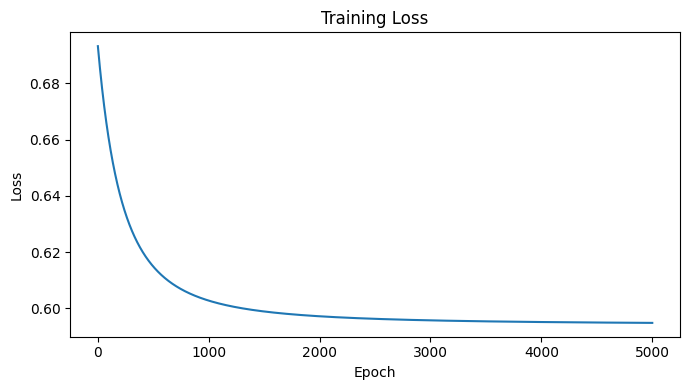

In [9]:
scaler = StandardScaler().fit(X_tv)
Xtv_s = scaler.transform(X_tv)
Xte_s = scaler.transform(X_test)
# Final binary logistic regression model using best parameters
clf = BinaryLogisticRegression(
    alpha=best_alpha,
    lr=best_lr,
    epochs=PARAMETERS['epochs']
)
print(f'\nRetraining on train+val (alpha={best_alpha}) ...')
# Train the final model using normalized train+validation set
clf.fit(Xtv_s, y_tv, print_every=500)
plt.figure(figsize=(7, 4))
plt.plot(range(1, clf.epochs + 1), clf.loss_history_)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [10]:
# Predict the probability of the difficult class on the test set
test_probs = clf.predict_proba(Xte_s)[:, 1]
y_pred_default = (test_probs >= PARAMETERS['default_threshold']).astype(int)
y_pred_tuned = (test_probs >= best_threshold).astype(int)

print(f'1. Threshold = {PARAMETERS["default_threshold"]} (default)')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_default):.3f}')
print(f'MCC       : {matthews_corrcoef(y_test, y_pred_default):.3f}')
print(f'F1        : {f1_score(y_test, y_pred_default):.3f}')
print(f'Precision : {precision_score(y_test, y_pred_default, zero_division=0):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred_default, zero_division=0):.3f}')

print(f'\n2. Threshold = {best_threshold:.2f} (tuned)')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_tuned):.3f}')
print(f'MCC       : {matthews_corrcoef(y_test, y_pred_tuned):.3f}')
print(f'F1        : {f1_score(y_test, y_pred_tuned):.3f}')
print(f'Precision : {precision_score(y_test, y_pred_tuned, zero_division=0):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred_tuned, zero_division=0):.3f}')

1. Threshold = 0.5 (default)
Accuracy  : 0.696
MCC       : 0.391
F1        : 0.700
Precision : 0.704
Recall    : 0.696

2. Threshold = 0.50 (tuned)
Accuracy  : 0.696
MCC       : 0.391
F1        : 0.700
Precision : 0.704
Recall    : 0.696


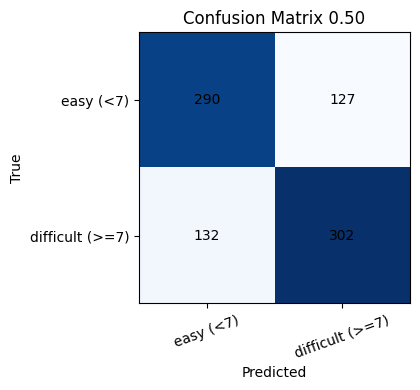

In [11]:
# Confusion matrix for better understanding
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix {best_threshold:.2f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0, 1], LABELS, rotation=20)
plt.yticks([0, 1], LABELS)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

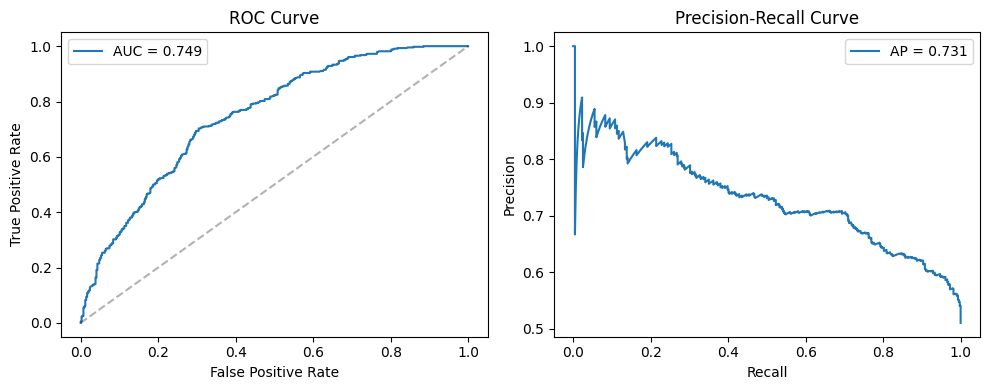

In [12]:
# Calculate false positive rate and true positive rate using test probability
fpr, tpr, _ = roc_curve(y_test, test_probs)
precision, recall, _ = precision_recall_curve(y_test, test_probs)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Receiver operating characteristic curve
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, test_probs):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision recall curve
axes[1].plot(recall, precision, label=f'AP = {average_precision_score(y_test, test_probs):.3f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
# Example word predictions
test_words = ['cat', 'dog', 'apple', 'elephant', 'metamorphosis', 'strength', 'beautiful', 'the']
print(f'\n{"Word":<20} {"Prob":>4}      {"Label":<12} Message')
print('-' * 75)
for w in test_words:
    predict_word(w, clf, scaler, PARAMETERS['threshold_age'], best_threshold)


Word                 Prob      Label        Message
---------------------------------------------------------------------------
cat                  p=0.236   easy         Most children aged 7 would likely know this word
dog                  p=0.199   easy         Most children aged 7 would likely know this word
apple                p=0.340   easy         Children aged 7 would likely know this word
elephant             p=0.751   difficult    This word is likely unfamiliar to children aged 7
metamorphosis        p=0.973   difficult    This word is likely unfamiliar to children aged 7
strength             p=0.411   easy         This word may or may not be familiar to children aged 7
beautiful            p=0.657   difficult    This word may be unfamiliar to children aged 7
the                  p=0.042   easy         Most children aged 7 would likely know this word


In [15]:
import json
# Save trained model weights and parameters to json for API deployment
model_artifact = {
    'w': clf.w_.tolist(),
    'b': float(clf.b_),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'best_threshold': float(best_threshold),
    'threshold_age': float(PARAMETERS['threshold_age']),
    'features': FEATURES
}

with open('word_difficulty_model.json', 'w') as f:
    json.dump(model_artifact, f)

print('Model saved.')

Model saved.
